# K-Nearest Neighbors on the Iris Dataset

This notebook demonstrates two K-nearest neighbors models implemented in the `jiayi_ml` package:

- `KNNClassifier`
- `KNNRegressor`

The main classification example uses the Iris dataset. The notebook also includes a simple one-dimensional regression example to show how KNN regression behaves for different values of `k`.

This example emphasizes:

1. Distance-based learning.
2. The effect of the number of neighbors.
3. Feature scaling.
4. Multiclass classification evaluation.
5. Decision boundary visualization.
6. KNN regression smoothing behavior.


## 1. Problem Statement

K-nearest neighbors is a non-parametric, instance-based learning algorithm.

Unlike linear regression or logistic regression, KNN does not learn a global equation during training. Instead, it stores the training data and makes predictions based on the closest training samples.

For classification:

> A test point is assigned the most common class among its nearest neighbors.

For regression:

> A test point is assigned the average target value among its nearest neighbors.

This notebook uses KNN for:

1. Multiclass classification on the Iris dataset.
2. One-dimensional regression on a synthetic nonlinear dataset.


## Modeling Hypothesis

Because the Iris classes are well separated by petal measurements, KNN should perform well for multiclass classification.

The main hypothesis is:

> Moderate values of k will classify Iris species accurately because nearby samples in standardized feature space often belong to the same species.

Very small k values may be more sensitive to local noise, while larger k values may produce smoother decision boundaries. The effect of k may be more visible in decision boundary plots than in aggregate test metrics for this relatively easy dataset.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import KNNClassifier, KNNRegressor
from jiayi_ml.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error,
    r2_score,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 2. Load the Iris Dataset

The Iris dataset contains measurements from three iris flower species:

- setosa
- versicolor
- virginica

Each sample has four numeric features:

- sepal length
- sepal width
- petal length
- petal width

The task is a **supervised multiclass classification** problem because the target has three known classes.


In [2]:
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = X.columns.tolist()

df = X.copy()
df["species"] = y
df["species_name"] = df["species"].map(lambda idx: target_names[idx])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

df.head()


Feature matrix shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 3. Exploratory Data Analysis

KNN depends directly on distances between samples. Therefore, feature distributions and feature scales matter.

The Iris features are all measured in centimeters, but their ranges still differ. Scaling is useful because KNN can otherwise be dominated by features with larger numeric ranges.


In [3]:
missing_values = df.isna().sum()
print("Total missing values:", int(missing_values.sum()))

summary = X.describe().T
summary


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.8433,0.8281,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.0573,0.4359,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.7580,1.7653,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.1993,0.7622,0.1,0.3,1.30,1.8,2.5


In [4]:
class_counts = df["species_name"].value_counts().reindex(target_names)

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
species_name,,
setosa,50,0.3333
versicolor,50,0.3333
virginica,50,0.3333


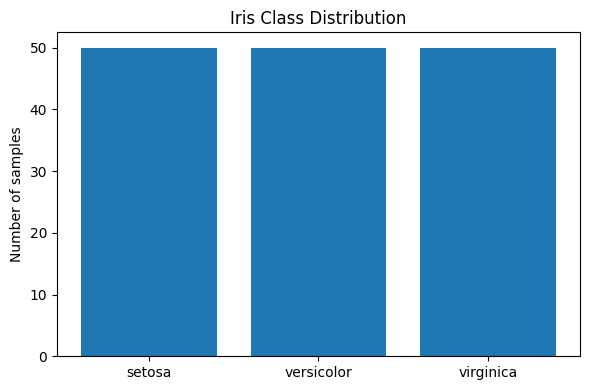

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts_df.index, class_counts_df["count"])
plt.ylabel("Number of samples")
plt.title("Iris Class Distribution")
plt.tight_layout()
plt.show()


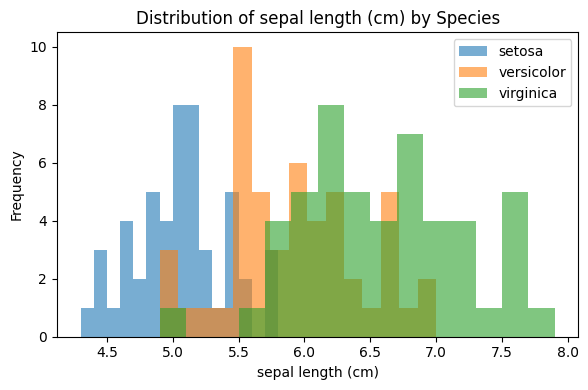

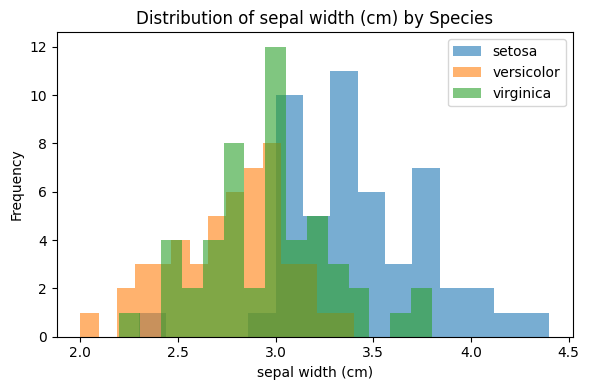

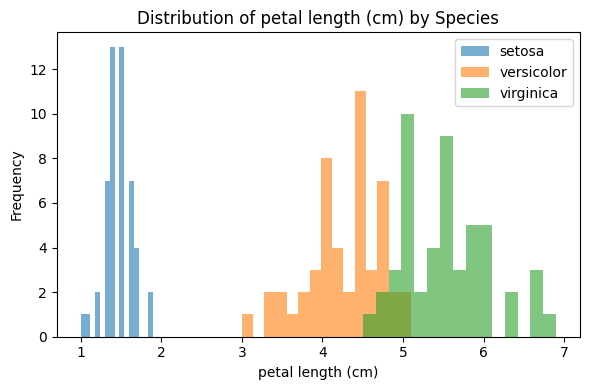

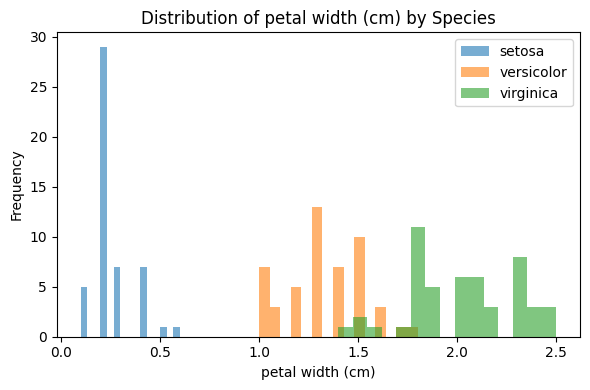

In [6]:
for feature in feature_names:
    plt.figure(figsize=(6, 4))
    for class_idx, class_name in enumerate(target_names):
        plt.hist(
            X.loc[y == class_idx, feature],
            bins=15,
            alpha=0.6,
            label=class_name,
        )
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature} by Species")
    plt.legend()
    plt.tight_layout()
    plt.show()


The class distributions are balanced, so accuracy is a reasonable first metric. However, because this is a multiclass classification problem, the confusion matrix is still important for identifying which species are confused with each other.

The feature histograms suggest that petal measurements are especially useful for separating species, while sepal measurements show more overlap.


## 4. Train/Test Split and Standardization

The data is split into training and test sets using stratification to preserve class proportions.

The scaler is fit only on the training set and then applied to the test set. This avoids data leakage.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=438,
    stratify=y.values,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training set shape: (112, 4)
Test set shape: (38, 4)
Training class counts: [37 37 38]
Test class counts: [13 13 12]


## 5. KNN Classification with Different Values of k

The number of neighbors controls the flexibility of the KNN classifier.

- Small `k`: more flexible, but more sensitive to noise.
- Large `k`: smoother decision boundary, but may underfit local structure.

The following experiment compares several values of `k` on the held-out test set.


In [8]:
k_values = [1, 3, 5, 11, 21]
classification_results = []

trained_classifiers = {}

for k in k_values:
    model = KNNClassifier(n_neighbors=k, metric="euclidean", weights="uniform")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    trained_classifiers[k] = model
    
    classification_results.append(
        {
            "k": k,
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_precision": np.mean(
                [precision_score(y_test, y_pred, pos_label=label) for label in np.unique(y_test)]
            ),
            "macro_recall": np.mean(
                [recall_score(y_test, y_pred, pos_label=label) for label in np.unique(y_test)]
            ),
            "macro_f1": np.mean(
                [f1_score(y_test, y_pred, pos_label=label) for label in np.unique(y_test)]
            ),
        }
    )

classification_results_df = pd.DataFrame(classification_results)
classification_results_df


,k,accuracy,macro_precision,macro_recall,macro_f1
0,1,0.9737,0.9762,0.9722,0.9732
1,3,0.9737,0.9762,0.9722,0.9732
2,5,0.9737,0.9762,0.9722,0.9732
3,11,0.9737,0.9762,0.9722,0.9732
4,21,0.9737,0.9762,0.9722,0.9732


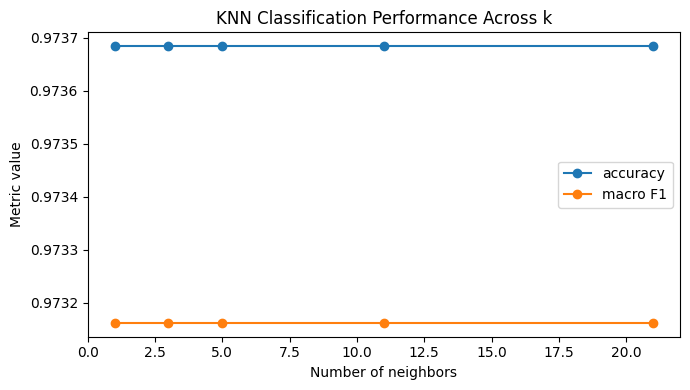

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(classification_results_df["k"], classification_results_df["accuracy"], marker="o", label="accuracy")
plt.plot(classification_results_df["k"], classification_results_df["macro_f1"], marker="o", label="macro F1")
plt.xlabel("Number of neighbors")
plt.ylabel("Metric value")
plt.title("KNN Classification Performance Across k")
plt.legend()
plt.tight_layout()
plt.show()


In this train/test split, all tested values of k produce the same test accuracy and macro F1 score. This suggests that the Iris dataset is relatively easy for KNN under this split, because the classes are well separated especially in petal measurements, and even the smallest k tested is sufficient for stable predictions.
Even though the aggregate test metrics do not change here, the choice of k still matters conceptually. Smaller k values produce more flexible and locally sensitive decision boundaries, while larger k values produce smoother boundaries. This bias-variance trade-off is visible in the decision boundary visualization below, and is demonstrated more clearly in the KNN regression section where different k values produce noticeably different results.

## 6. Confusion Matrix for the Selected Model

We select `k = 5` as a reasonable middle value. It is flexible enough to capture local structure while being less sensitive to noise than `k = 1`.


In [10]:
selected_k = 5
selected_model = trained_classifiers[selected_k]
y_pred_selected = selected_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_selected, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=[f"true {name}" for name in target_names],
    columns=[f"predicted {name}" for name in target_names],
)

cm_df


,predicted setosa,predicted versicolor,predicted virginica
true setosa,13,0,0
true versicolor,0,13,0
true virginica,0,1,11


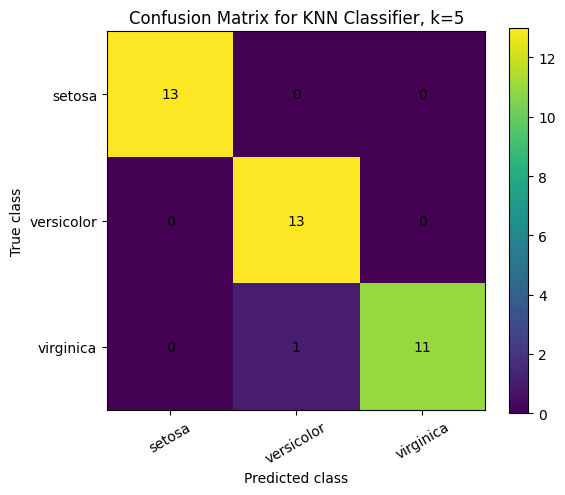

In [11]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.xticks([0, 1, 2], target_names, rotation=30)
plt.yticks([0, 1, 2], target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title(f"Confusion Matrix for KNN Classifier, k={selected_k}")
plt.colorbar()
plt.tight_layout()
plt.show()


The confusion matrix identifies which species are most often confused. In many Iris analyses, setosa is easiest to separate, while versicolor and virginica can overlap more because their measurements are more similar.


## 7. Decision Boundary Visualization Using Two Features

KNN decision boundaries are easiest to visualize in two dimensions.

The full model above used all four Iris features. For visualization only, this section uses:

- petal length
- petal width

These two features are chosen because the exploratory analysis suggests that petal measurements separate species well.


In [12]:
petal_features = ["petal length (cm)", "petal width (cm)"]
X_petal = X[petal_features].values

X_petal_train, X_petal_test, y_petal_train, y_petal_test = train_test_split(
    X_petal,
    y.values,
    test_size=0.25,
    random_state=438,
    stratify=y.values,
)

petal_scaler = StandardScaler()
X_petal_train_scaled = petal_scaler.fit_transform(X_petal_train)
X_petal_test_scaled = petal_scaler.transform(X_petal_test)

x_min, x_max = X_petal_train_scaled[:, 0].min() - 0.5, X_petal_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_petal_train_scaled[:, 1].min() - 0.5, X_petal_train_scaled[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)

grid = np.c_[xx.ravel(), yy.ravel()]


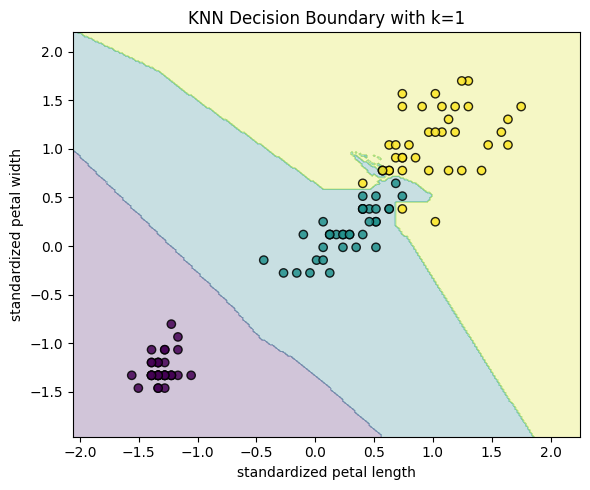

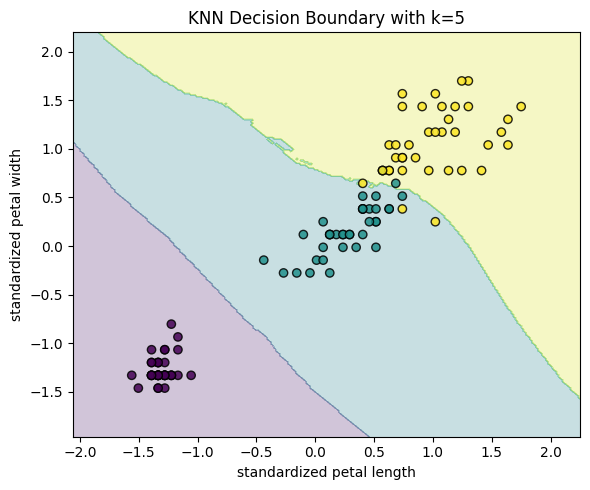

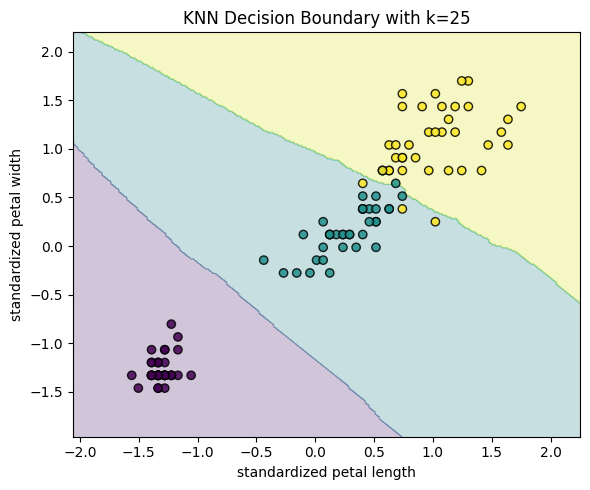

In [13]:
for k in [1, 5, 25]:
    boundary_model = KNNClassifier(n_neighbors=k)
    boundary_model.fit(X_petal_train_scaled, y_petal_train)
    grid_predictions = boundary_model.predict(grid).reshape(xx.shape)
    
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, grid_predictions, alpha=0.25)
    plt.scatter(
        X_petal_train_scaled[:, 0],
        X_petal_train_scaled[:, 1],
        c=y_petal_train,
        edgecolors="k",
        alpha=0.85,
    )
    plt.xlabel("standardized petal length")
    plt.ylabel("standardized petal width")
    plt.title(f"KNN Decision Boundary with k={k}")
    plt.tight_layout()
    plt.show()


The decision boundary visualization shows how `k` changes model flexibility.

- With `k = 1`, the boundary can be very jagged because each point has strong influence.
- With moderate `k`, the boundary becomes smoother.
- With very large `k`, the model may become too smooth and can ignore smaller local patterns.

This illustrates the bias-variance trade-off in KNN.


## 8. KNN Regression on a Synthetic Nonlinear Dataset

KNN can also be used for regression.

To demonstrate this, we generate a one-dimensional nonlinear dataset. The true pattern is smooth, but the observations include noise.

This example is useful because it shows how the number of neighbors controls smoothing.


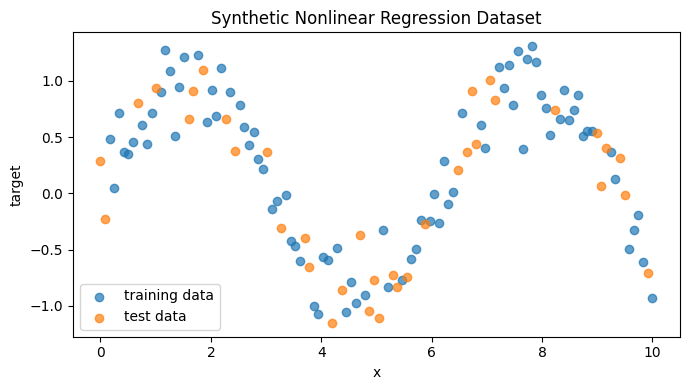

In [14]:
rng = np.random.default_rng(438)

X_reg = np.linspace(0, 10, 120).reshape(-1, 1)
y_reg = np.sin(X_reg).ravel() + 0.25 * rng.normal(size=X_reg.shape[0])

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=438,
)

reg_scaler = StandardScaler()
X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = reg_scaler.transform(X_reg_test)

plt.figure(figsize=(7, 4))
plt.scatter(X_reg_train, y_reg_train, alpha=0.7, label="training data")
plt.scatter(X_reg_test, y_reg_test, alpha=0.7, label="test data")
plt.xlabel("x")
plt.ylabel("target")
plt.title("Synthetic Nonlinear Regression Dataset")
plt.legend()
plt.tight_layout()
plt.show()


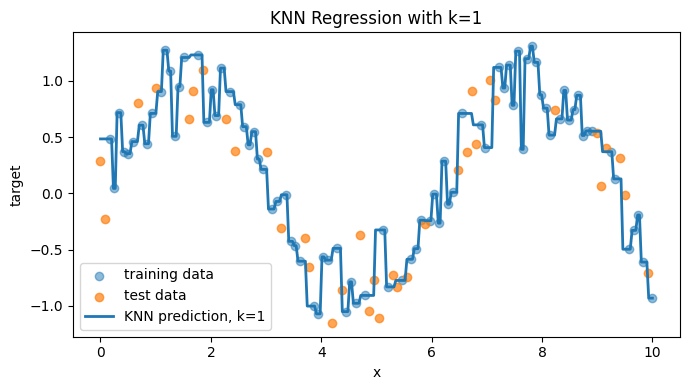

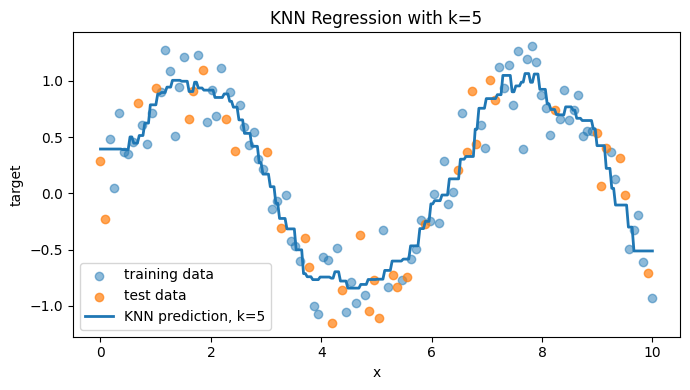

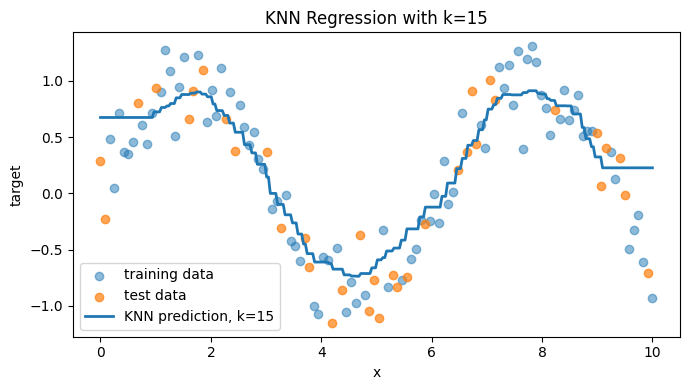

,k,MSE,RMSE,MAE,R2
0,1,0.1231,0.3509,0.2899,0.7384
1,5,0.0675,0.2598,0.2033,0.8565
2,15,0.1049,0.3239,0.2413,0.7771


In [15]:
regression_k_values = [1, 5, 15]
regression_results = []

x_grid_original = np.linspace(0, 10, 300).reshape(-1, 1)
x_grid_scaled = reg_scaler.transform(x_grid_original)

for k in regression_k_values:
    reg_model = KNNRegressor(n_neighbors=k)
    reg_model.fit(X_reg_train_scaled, y_reg_train)
    
    y_reg_pred = reg_model.predict(X_reg_test_scaled)
    y_grid_pred = reg_model.predict(x_grid_scaled)
    
    regression_results.append(
        {
            "k": k,
            "MSE": mean_squared_error(y_reg_test, y_reg_pred),
            "RMSE": root_mean_squared_error(y_reg_test, y_reg_pred),
            "MAE": mean_absolute_error(y_reg_test, y_reg_pred),
            "R2": r2_score(y_reg_test, y_reg_pred),
        }
    )
    
    plt.figure(figsize=(7, 4))
    plt.scatter(X_reg_train, y_reg_train, alpha=0.5, label="training data")
    plt.scatter(X_reg_test, y_reg_test, alpha=0.7, label="test data")
    plt.plot(x_grid_original, y_grid_pred, linewidth=2, label=f"KNN prediction, k={k}")
    plt.xlabel("x")
    plt.ylabel("target")
    plt.title(f"KNN Regression with k={k}")
    plt.legend()
    plt.tight_layout()
    plt.show()

regression_results_df = pd.DataFrame(regression_results)
regression_results_df


The regression plots show the smoothing behavior of KNN.

- Small `k` follows local variation closely and may overfit noise.
- Larger `k` produces smoother predictions but may underfit sharp local structure.
- The best value of `k` depends on the noise level and the underlying function complexity.


## 9. Interpretation

KNN is simple and intuitive, but it depends heavily on the distance metric, feature scaling, and the choice of `k`.

For the Iris classification task, KNN performs well because the classes are relatively well separated in the feature space.

For the synthetic regression task, KNN demonstrates local averaging. This makes it flexible, but also sensitive to the number of neighbors.


## 10. Limitations

KNN has several important limitations:

1. It can be computationally expensive at prediction time because it compares each test point to training samples.
2. It is sensitive to feature scaling.
3. It can perform poorly in high-dimensional spaces because distances become less informative.
4. The choice of `k` strongly affects model behavior.
5. It does not provide coefficients or a compact parametric model.
6. It can be affected by irrelevant or noisy features.

Despite these limitations, KNN is a useful baseline and an intuitive example of distance-based learning.


## 11. Conclusion

This notebook demonstrated KNN classification and regression using custom implementations from `jiayi_ml`.

Key takeaways:

- KNN is an instance-based learning algorithm.
- Feature scaling is important because KNN relies on distances.
- Smaller `k` values produce more flexible models.
- Larger `k` values produce smoother models.
- Decision boundaries help visualize how KNN behaves.
- KNN can be used for both classification and regression.
